In [44]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Load debug files
preds0 = torch.load('debug_preds_at_loss0.pt', map_location='cpu')
targets0 = torch.load('debug_targets_at_loss0.pt', map_location='cpu')
input0 = torch.load('debug_input_at_loss0.pt', map_location='cpu')

preds1 = torch.load('debug_preds_at_loss1.pt', map_location='cpu')
targets1 = torch.load('debug_targets_at_loss1.pt', map_location='cpu')
input1 = torch.load('debug_input_at_loss1.pt', map_location='cpu')

preds2 = torch.load('debug_preds_at_loss2.pt', map_location='cpu')
targets2 = torch.load('debug_targets_at_loss2.pt', map_location='cpu')
input2 = torch.load('debug_input_at_loss2.pt', map_location='cpu')

# after_copy = torch.load('ori_img_bev_embed_after_copy.pt')
# head = torch.load('ori_img_bev_embed_head.pt')

print("Debug files loaded successfully.")

Debug files loaded successfully.


In [32]:
# Define helper function to go between data formats
# from [Batch, Channels, Height, Width] to [Batch, Values, Channels]
import numpy as np

def bvc_to_bchw(tensor, H=200, W=200):
    """
    Convert [B, V, C] -> [B, C, H, W].
    Accepts torch.Tensor or numpy.ndarray. If H and W don't match V, will try to infer square side.
    """
    B, V, C = tensor.shape
    if V != H*W:
        raise ValueError(f"H and W are not product from V, please specify what H and W you want")
    
    if isinstance(tensor, torch.Tensor):
        tensor = tensor.reshape(B, H, W, C)
        tensor = tensor.permute(0, 3, 2, 1).contiguous()
        return tensor
    elif isinstance(tensor, np.ndarray):
        tensor = tensor.copy()
        tensor = tensor.reshape(B, H, W, C)
        tensor = np.transpose(tensor, (0, 3, 2, 1))
        return tensor
    else:
        raise TypeError("Expected torch.TEnsor or numpy.ndarray")
    
def bchw_to_bvc(tensor):
    """
    Convert [B, C, H, W] -> [B, V, C] where V = H*W.
    Accepts torch.Tensor or numpy.ndarray.
    """
    B, C, H, W = tensor.shape
    if isinstance(tensor, torch.Tensor):
        tensor = tensor.reshape(B, C, H*W)
        tensor = tensor.permute(0, 2, 1).contiguous()  
        return tensor
    elif isinstance(tensor, np.ndarray):
        tensor = tensor.copy()
        tensor = tensor.reshape(B, C, H*W)
        tensor = np.transpose(tensor, (0, 2, 1))
        return tensor



In [65]:
# Inspect structure of loaded data
def inspect_tensor_or_dict(data, name="data", depth=0):
    indent = "  " * depth
    if isinstance(data, torch.Tensor):
        print(f"{indent}{name}: Tensor, shape={data.shape}, dtype={data.dtype}")
        print(f"{indent}  min={data.min().item():.6f}, max={data.max().item():.6f}, mean={data.mean().item():.6f}, std={data.std().item():.6f}")
    elif isinstance(data, dict):
        print(f"{indent}{name}: Dict with {len(data)} keys")
        for k, v in data.items():
            inspect_tensor_or_dict(v, str(k), depth + 1)
    elif isinstance(data, (list, tuple)):
        print(f"{indent}{name}: {type(data).__name__} with {len(data)} items")
        for i, v in enumerate(data[:5]):  # Show first 5
            inspect_tensor_or_dict(v, f"[{i}]", depth + 1)
        if len(data) > 5:
            print(f"{indent}  ... and {len(data) - 5} more items")
    else:
        print(f"{indent}{name}: {type(data).__name__}")

print("=== Predictions ===")
inspect_tensor_or_dict(preds0, "preds")
print("\n=== Targets ===")
inspect_tensor_or_dict(targets0, "targets")

=== Predictions ===
preds: Tensor, shape=torch.Size([5, 40000, 256]), dtype=torch.float32
  min=-2.729244, max=2.557347, mean=-0.007300, std=0.408621

=== Targets ===
targets: Tensor, shape=torch.Size([5, 40000, 256]), dtype=torch.float32
  min=-4.947158, max=4.548199, mean=-0.003674, std=0.637657


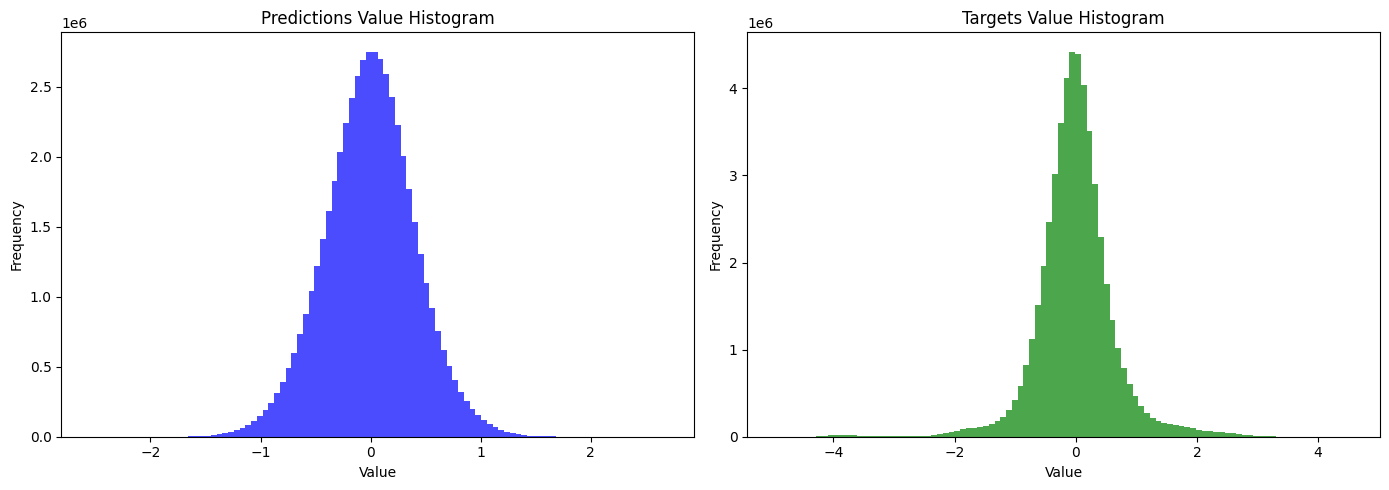

Predictions - Min: -2.548490, Max: 2.677064, Mean: -0.004361, Std: 0.410139
Targets - Min: -4.946515, Max: 4.545475, Mean: -0.003674, Std: 0.637638


In [3]:
# Plot histograms of predictions and targets
def get_flat_tensor(data):
    """Recursively extract and flatten all tensors"""
    if isinstance(data, torch.Tensor):
        return data.flatten()
    elif isinstance(data, dict):
        tensors = [get_flat_tensor(v) for v in data.values()]
        tensors = [t for t in tensors if t is not None]
        return torch.cat(tensors) if tensors else None
    elif isinstance(data, (list, tuple)):
        tensors = [get_flat_tensor(v) for v in data]
        tensors = [t for t in tensors if t is not None]
        return torch.cat(tensors) if tensors else None
    return None

preds_flat = get_flat_tensor(preds)
targets_flat = get_flat_tensor(targets)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

if preds_flat is not None:
    preds_np = preds_flat.cpu().numpy()
    axs[0].hist(preds_np, bins=100, alpha=0.7, color='blue')
    axs[0].set_title('Predictions Value Histogram')
    axs[0].set_xlabel('Value')
    axs[0].set_ylabel('Frequency')

if targets_flat is not None:
    targets_np = targets_flat.cpu().numpy()
    axs[1].hist(targets_np, bins=100, alpha=0.7, color='green')
    axs[1].set_title('Targets Value Histogram')
    axs[1].set_xlabel('Value')
    axs[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print statistics
if preds_flat is not None:
    print(f"Predictions - Min: {preds_flat.min().item():.6f}, Max: {preds_flat.max().item():.6f}, Mean: {preds_flat.mean().item():.6f}, Std: {preds_flat.std().item():.6f}")
if targets_flat is not None:
    print(f"Targets - Min: {targets_flat.min().item():.6f}, Max: {targets_flat.max().item():.6f}, Mean: {targets_flat.mean().item():.6f}, Std: {targets_flat.std().item():.6f}")

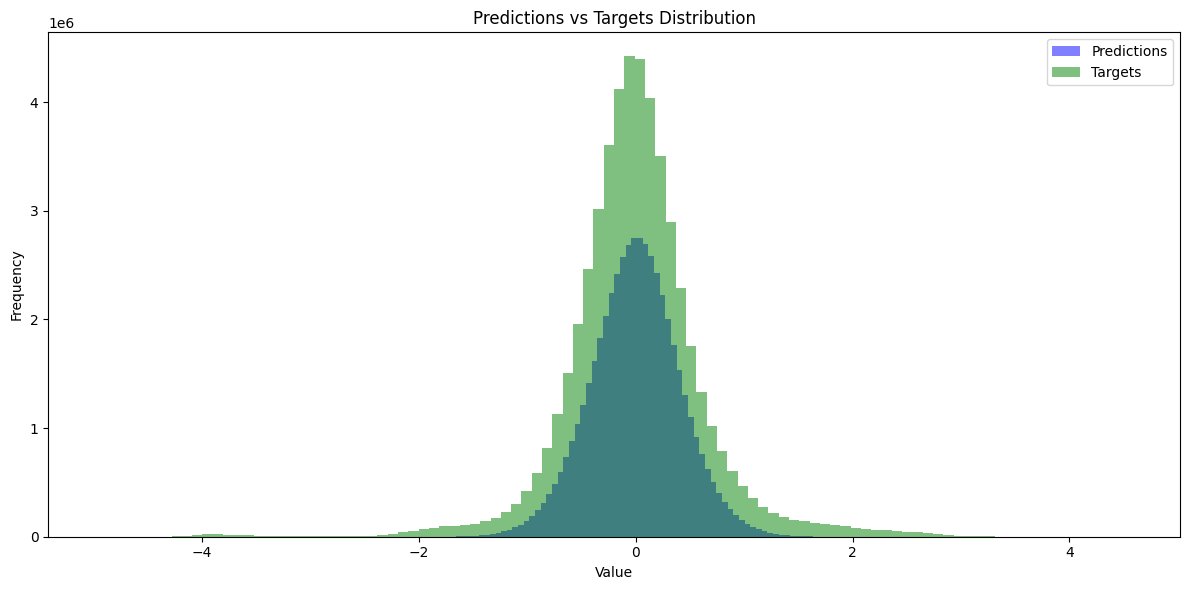

In [4]:
# Overlayed histogram comparison
fig, ax = plt.subplots(figsize=(12, 6))

if preds_flat is not None and targets_flat is not None:
    ax.hist(preds_np, bins=100, alpha=0.5, color='blue', label='Predictions')
    ax.hist(targets_np, bins=100, alpha=0.5, color='green', label='Targets')
    ax.set_title('Predictions vs Targets Distribution')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

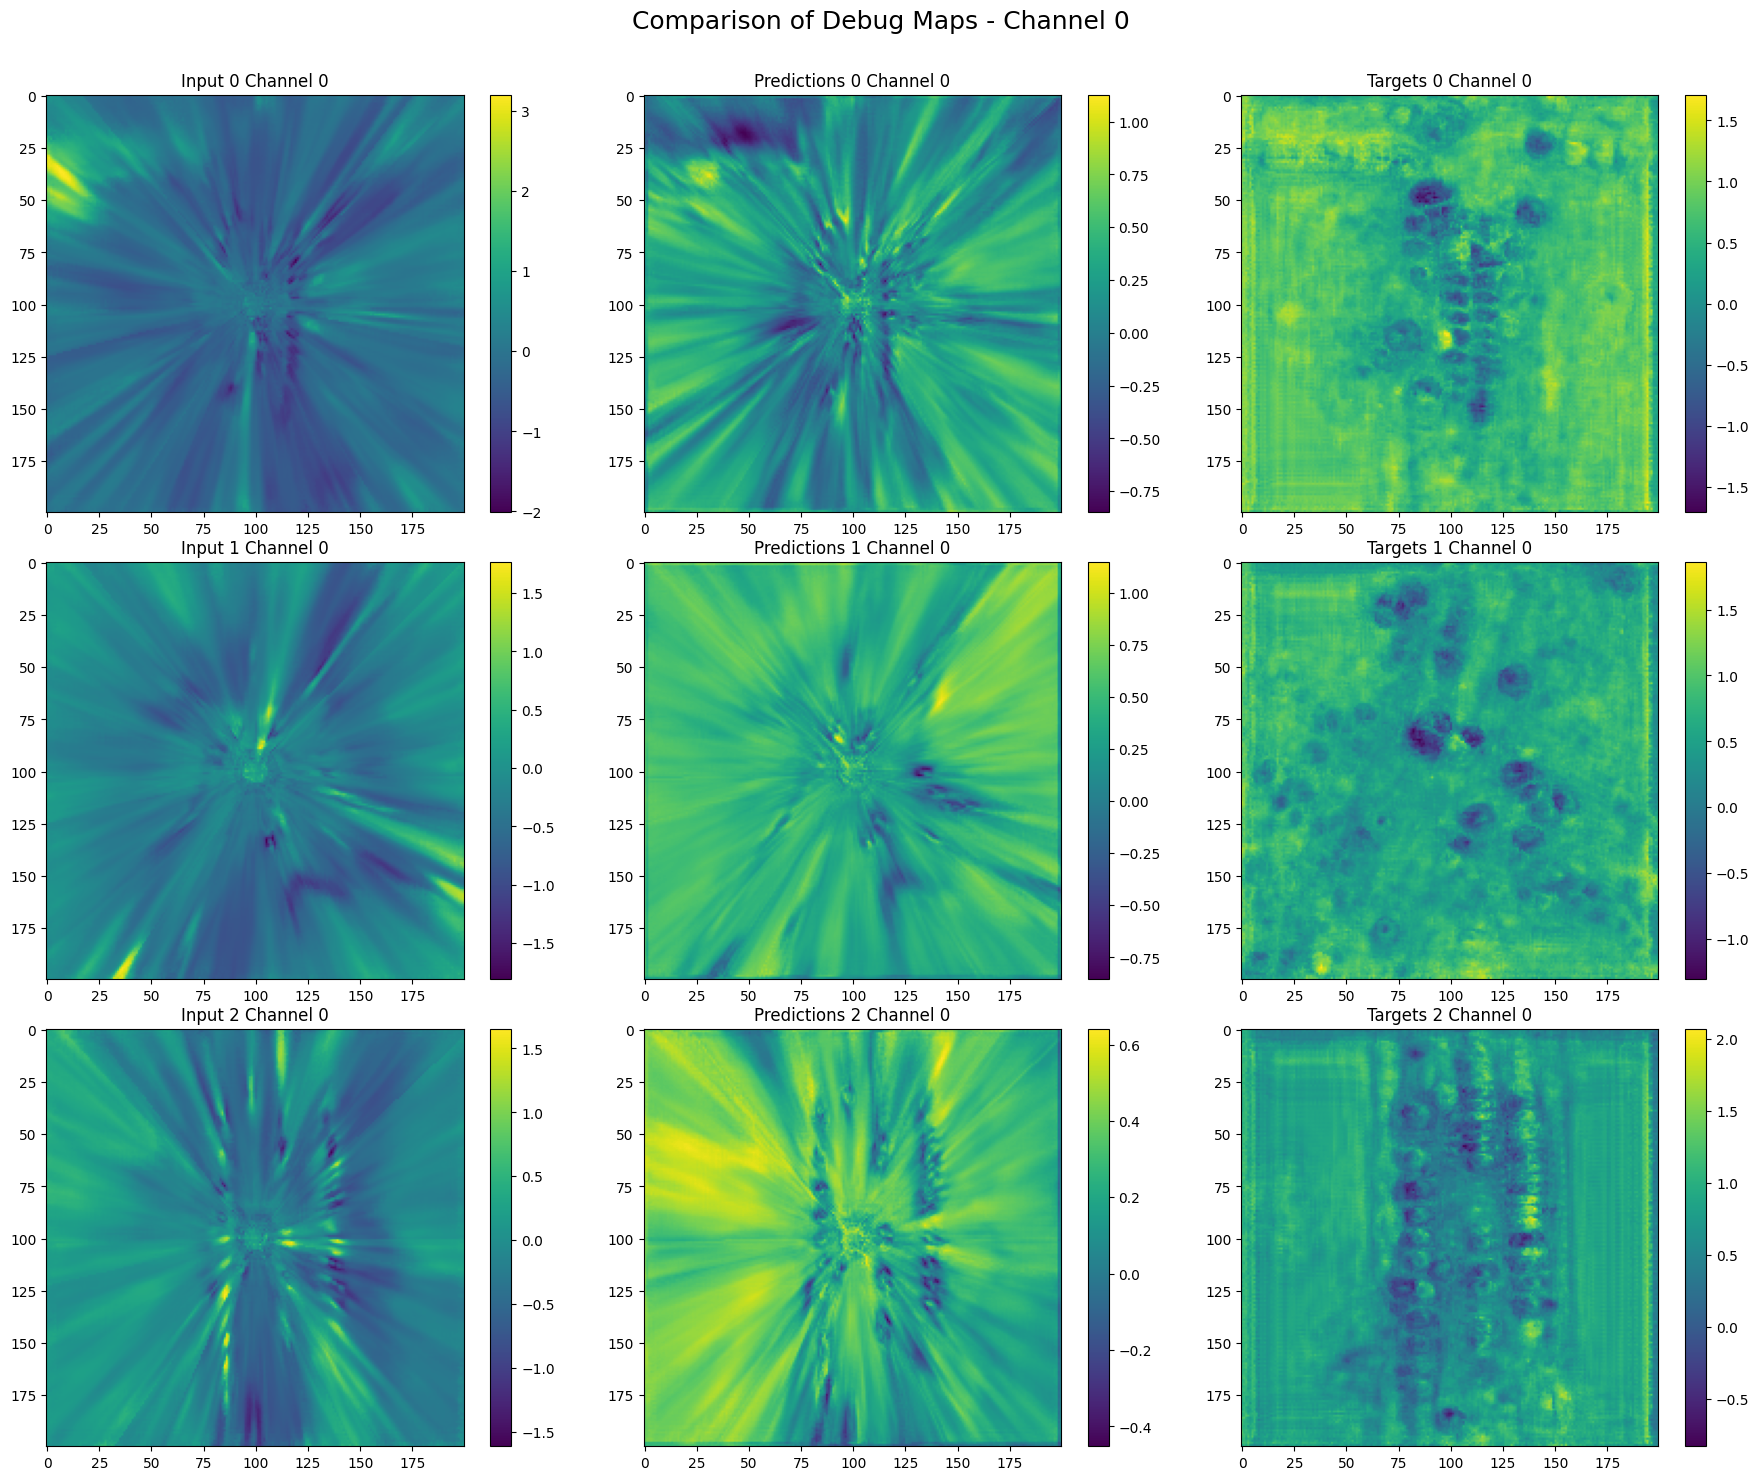

In [45]:
# If tensors are 2D/3D (like feature maps), visualize samples
def visualize_tensor_comparison(input_data, preds_data, targets_data, num_channels=3, grid_size=(200, 200), 
                                 input_name="Input", preds_name="Predictions", targets_name="Targets"):
    """Visualize input, preds and targets side by side for specified number of channels.
    Input shape: (B, N, C) - reshaped to (B, H, W, C) using grid_size.
    """
    if isinstance(input_data, torch.Tensor) and isinstance(preds_data, torch.Tensor) and isinstance(targets_data, torch.Tensor):
        if input_data.dim() == 3 and preds_data.dim() == 3 and targets_data.dim() == 3:  # (B, N, C)
            B, N, C = preds_data.shape
            H, W = grid_size
            
            # Reshape to (B, H, W, C)
            input_reshaped = input_data[0].reshape(H, W, -1)  # First batch, may have different C
            preds_reshaped = preds_data[0].reshape(H, W, C)  # First batch
            targets_reshaped = targets_data[0].reshape(H, W, C)
            
            num_channels = min(num_channels, C)
            fig, axs = plt.subplots(num_channels, 3, figsize=(18, 4 * num_channels))
            fig.suptitle(f'{input_name} vs {preds_name} vs {targets_name} - First {num_channels} Channels (first batch)')
            
            if num_channels == 1:
                axs = axs.reshape(1, 3)
            
            for i in range(num_channels):
                # Input
                input_ch = min(i, input_reshaped.shape[2] - 1)  # Handle different channel count
                im_input = axs[i, 0].imshow(input_reshaped[:, :, input_ch].cpu().numpy(), cmap='viridis')
                axs[i, 0].set_title(f'{input_name} Channel {input_ch}')
                plt.colorbar(im_input, ax=axs[i, 0])
                
                # Predictions
                im_pred = axs[i, 1].imshow(preds_reshaped[:, :, i].cpu().numpy(), cmap='viridis')
                axs[i, 1].set_title(f'{preds_name} Channel {i}')
                plt.colorbar(im_pred, ax=axs[i, 1])
                
                # Targets
                im_tgt = axs[i, 2].imshow(targets_reshaped[:, :, i].cpu().numpy(), cmap='viridis')
                axs[i, 2].set_title(f'{targets_name} Channel {i}')
                plt.colorbar(im_tgt, ax=axs[i, 2])
            
            plt.tight_layout()
            plt.show()



def compare_debug_maps(inputs, preds, targets, channel=0, grid_size=(200, 200), input_name="Input", preds_name="Predictions", targets_name="Targets"):
    """
    Compare multiple debug maps (input, preds, targets) for a specific channel.
    Each row is a different debug file (0, 1, 2).
    """
    num_debugs = len(inputs)
    fig, axs = plt.subplots(num_debugs, 3, figsize=(18, 5 * num_debugs))
    fig.suptitle(f'Comparison of Debug Maps - Channel {channel}', fontsize=18)
    for i in range(num_debugs):
        # Reshape to (H, W, C)
        input_reshaped = inputs[i][0].reshape(grid_size[0], grid_size[1], -1)
        preds_reshaped = preds[i][0].reshape(grid_size[0], grid_size[1], -1)
        targets_reshaped = targets[i][0].reshape(grid_size[0], grid_size[1], -1)
        # Clamp channel index
        ch_input = min(channel, input_reshaped.shape[2] - 1)
        ch_pred = min(channel, preds_reshaped.shape[2] - 1)
        ch_target = min(channel, targets_reshaped.shape[2] - 1)
        # Input
        im0 = axs[i, 0].imshow(input_reshaped[:, :, ch_input].cpu().numpy(), cmap='viridis')
        axs[i, 0].set_title(f'{input_name} {i} Channel {ch_input}')
        plt.colorbar(im0, ax=axs[i, 0])
        # Predictions
        im1 = axs[i, 1].imshow(preds_reshaped[:, :, ch_pred].cpu().numpy(), cmap='viridis')
        axs[i, 1].set_title(f'{preds_name} {i} Channel {ch_pred}')
        plt.colorbar(im1, ax=axs[i, 1])
        # Targets
        im2 = axs[i, 2].imshow(targets_reshaped[:, :, ch_target].cpu().numpy(), cmap='viridis')
        axs[i, 2].set_title(f'{targets_name} {i} Channel {ch_target}')
        plt.colorbar(im2, ax=axs[i, 2])
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# Example usage: compare channel 0 across all debug files
compare_debug_maps(
    inputs=[input0, input1, input2],
    preds=[preds0, preds1, preds2],
    targets=[targets0, targets1, targets2],
    channel=0,  # Change this to select another channel
    grid_size=(200, 200)
)

In [ ]:
print("=== Visualizing Input vs Predictions vs Targets ===")
visualize_tensor_comparison(input, preds0, targets0, num_channels=3, grid_size=(200, 200))

In [62]:
def compare_tensors_exact(tensor_list, names):
    """
    Compare tensors for exact equality and print results.
    Args:
        tensor_list: list of torch.Tensor objects
        names: list of names for each tensor
    """
    n = len(tensor_list)
    for i in range(n):
        for j in range(i + 1, n):
            t1, t2 = tensor_list[i], tensor_list[j]
            if t1.shape != t2.shape:
                print(f"{names[i]} vs {names[j]}: Shape mismatch {t1.shape} vs {t2.shape}")
            else:
                exact = torch.equal(t1, t2)
                max_abs_diff = (t1 - t2).abs().max().item()
                print(f"{names[i]} vs {names[j]}: {'EXACT MATCH' if exact else 'DIFFERENT'} (max abs diff: {max_abs_diff:.6e})")

# Compare inputs
compare_tensors_exact([input0, input1, input2], ["input0", "input1", "input2"])

# Compare predictions
compare_tensors_exact([preds0, preds1, preds2], ["preds0", "preds1", "preds2"])

# Compare targets
compare_tensors_exact([targets0, targets1, targets2], ["targets0", "targets1", "targets2"])

input0 vs input1: DIFFERENT (max abs diff: 7.053583e+00)
input0 vs input2: DIFFERENT (max abs diff: 7.330962e+00)
input1 vs input2: DIFFERENT (max abs diff: 5.303152e+00)
preds0 vs preds1: DIFFERENT (max abs diff: 2.259140e+00)
preds0 vs preds2: DIFFERENT (max abs diff: 2.286235e+00)
preds1 vs preds2: DIFFERENT (max abs diff: 1.661853e+00)
targets0 vs targets1: DIFFERENT (max abs diff: 4.500555e+00)
targets0 vs targets2: DIFFERENT (max abs diff: 4.432980e+00)
targets1 vs targets2: DIFFERENT (max abs diff: 4.588761e+00)


In [53]:
def plot_all_category_differences_bchw(
    inputs, preds, targets, channel=0, cmap='bwr'
):
    categories = {
        'Inputs': inputs,
        'Predictions': preds,
        'Targets': targets
    }

    for cat_name, cat_list in categories.items():
        n = len(cat_list)
        if n < 2:
            print(f"Skipping {cat_name}: need at least 2 tensors")
            continue

        fig, axes = plt.subplots(1, 3, figsize=(12, 6))
        axes = axes.flatten()

        fig.suptitle(
            f"{cat_name} - Difference Heatmaps (Channel {channel})",
            fontsize=16
        )

        plot_idx = 0
        for i in range(n):
            for j in range(i + 1, n):
                a = cat_list[i][0, channel]  # (H, W)
                b = cat_list[j][0, channel]
                diff = (a - b).cpu().numpy()

                vmax = np.max(np.abs(diff))
                vmin = -vmax

                ax = axes[plot_idx]
                im = ax.imshow(diff, cmap=cmap, vmin=vmin, vmax=vmax)
                ax.set_title(f"{i} vs {j}")
                ax.axis("off")

                # individual colorbar per subplot
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

                plot_idx += 1

        # Turn off unused subplots
        # for ax in axes[plot_idx:]:
        #     ax.axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

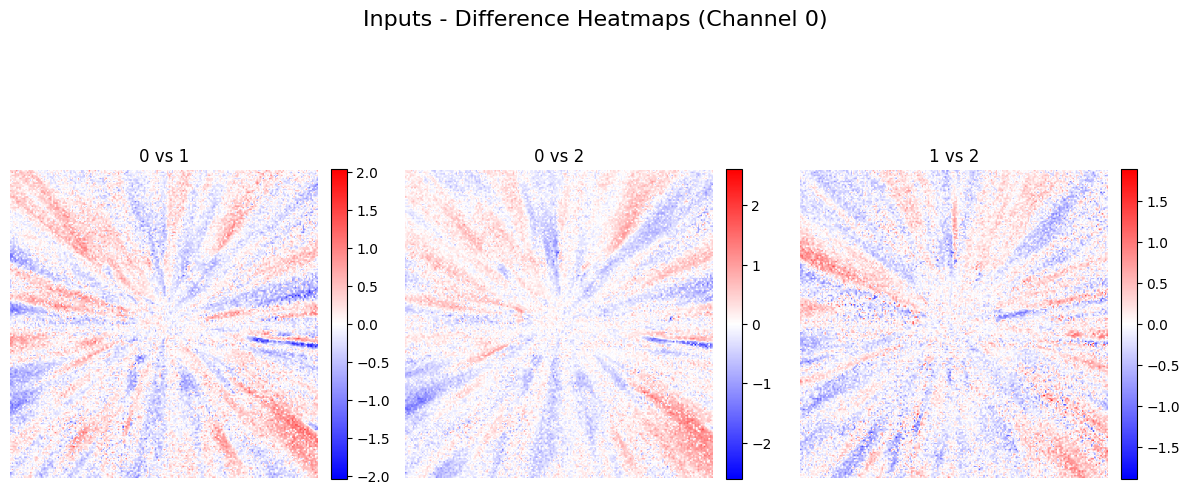

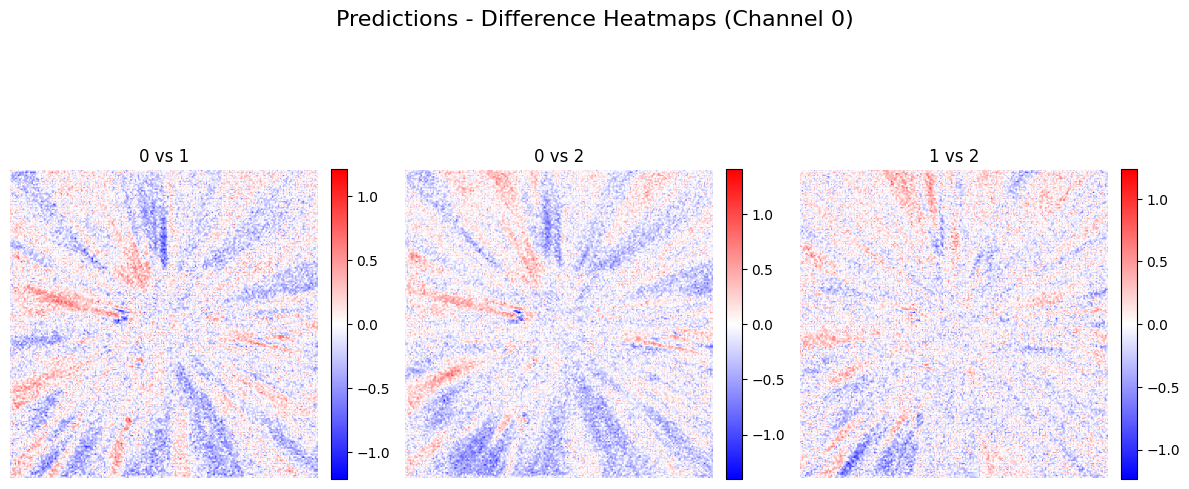

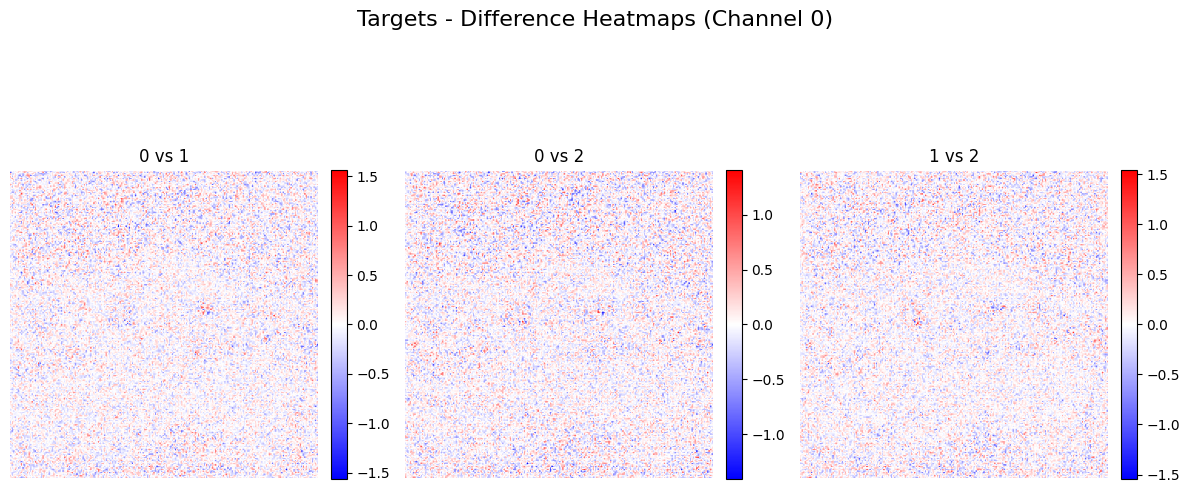

In [54]:
plot_all_category_differences_bchw( inputs=[bvc_to_bchw(input0), bvc_to_bchw(input1), bvc_to_bchw(input2)], preds=[bvc_to_bchw(preds0), bvc_to_bchw(preds1), bvc_to_bchw(preds2)], targets=[bvc_to_bchw(targets0), bvc_to_bchw(targets1), bvc_to_bchw(targets2)], channel=0, cmap='bwr' )

In [ ]:
# Compute and visualize error/difference if shapes match
if isinstance(preds, torch.Tensor) and isinstance(targets, torch.Tensor):
    if preds.shape == targets.shape:
        diff = preds - targets
        abs_diff = torch.abs(diff)
        
        print(f"Difference Stats:")
        print(f"  Min: {diff.min().item():.6f}, Max: {diff.max().item():.6f}")
        print(f"  Mean: {diff.mean().item():.6f}, Std: {diff.std().item():.6f}")
        print(f"  Mean Abs Error: {abs_diff.mean().item():.6f}")
        print(f"  MSE: {(diff**2).mean().item():.6f}")
        
        # Visualize difference histogram
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.hist(diff.cpu().numpy().flatten(), bins=100, alpha=0.7, color='red')
        ax.set_title('Prediction - Target Difference Histogram')
        ax.set_xlabel('Difference')
        ax.set_ylabel('Frequency')
        plt.tight_layout()
        plt.show()
        
        # Visualize absolute error spatial map if 4D
        if diff.dim() == 4:
            mean_abs_error = abs_diff.mean(dim=1)[0]  # Mean over channels for first batch
            fig, ax = plt.subplots(figsize=(10, 8))
            im = ax.imshow(mean_abs_error.cpu().numpy(), cmap='hot')
            ax.set_title('Mean Absolute Error Map (averaged over channels)')
            plt.colorbar(im, ax=ax)
            plt.tight_layout()
            plt.show()
    else:
        print(f"Shape mismatch: preds {preds.shape} vs targets {targets.shape}")